# Data Understanding

Walmart have been provides a public dataset on Kaggle called [Walmart Dataset](https://www.kaggle.com/datasets/yasserh/walmart-dataset) with historical sales and related variables. In this phase, the goal is to explore the data's structure, completeness, and quality to confirm whether it is suitable for a sales-forecasting approach.

## Data source Inventory and Quality
The main source to use is the previous mentioned Walmart Dataset which is disposed on Kaggle by the collaborator [M Yasser H](https://www.kaggle.com/yasserh). 

### Walmart Dataset

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
walmart_ds = pd.read_csv("../data/raw/walmart.csv")
walmart_ds["Date"] = pd.to_datetime(
    walmart_ds["Date"],
    format="%d-%m-%Y"
)
print("Shape: \n",walmart_ds.shape)
print("Minimum and maximum date: \n", walmart_ds["Date"].agg(["min", "max"]))
walmart_ds["Weekly_Sales"].describe()

Shape: 
 (6435, 8)
Minimum and maximum date: 
 min   2010-02-05
max   2012-10-26
Name: Date, dtype: datetime64[ns]


count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64


Walmart Dataset contains 6435 records of total sales weekly by each store between 2010-02-05 and 2012-10-26 and has 8 columns:
| Column | Description |
| --- | --- |
| `Store`| The store number |
| `Date` | The week of sales |
| `Weekly_Sales`| Sales for the given store |
| `Holiday_Flag`| Whether the week is a special holiday week (1) or no holiday week (0) |
| `Temperature`| Temperature on the day of sale|
| `Fuel_Price`| Cost of fuel in the region|
| `CPI`| Prevailing consumer price index|
| `Unemployment`| Prevailing unemployment rate|

The minimun fields are present which are `Store`, `Date` and `Weekly_Sales` to predict future weekly sales for a specific store. Then, there are other regional factors and holiday weeks where usually Walmart should make promotional markdowns.

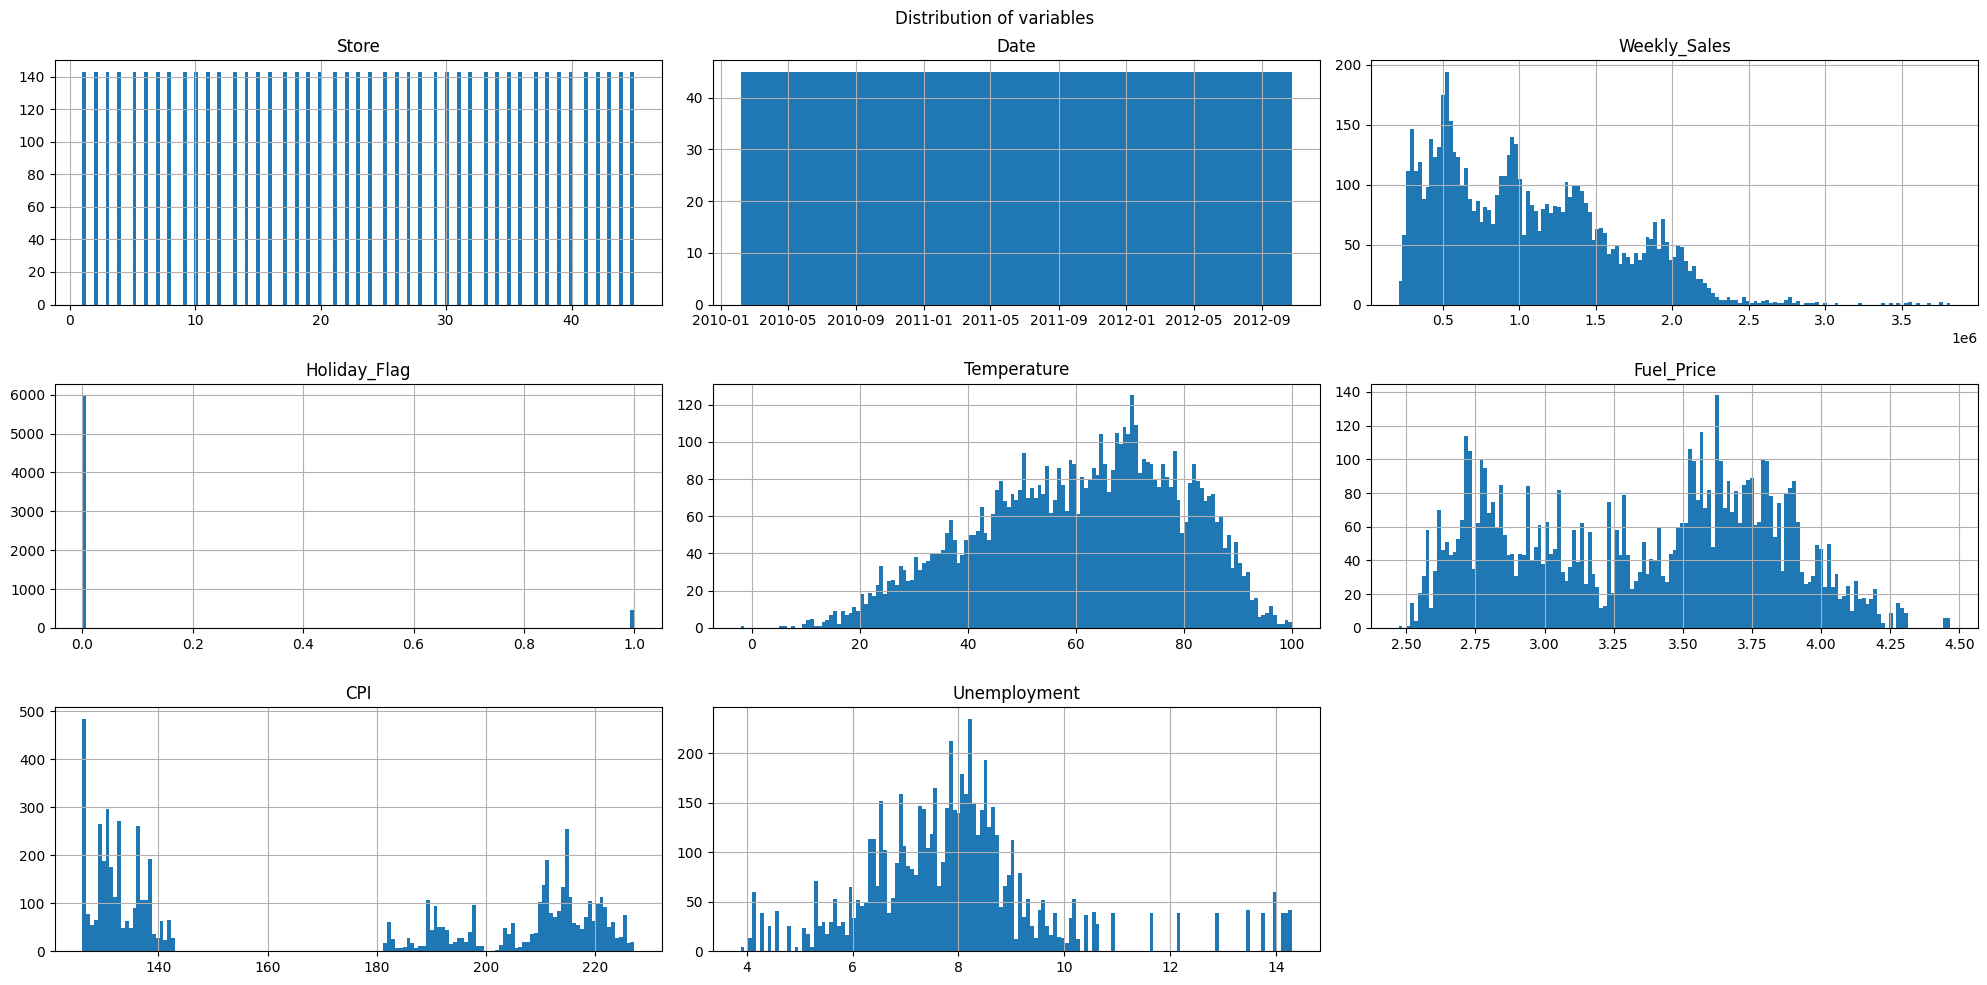

In [23]:
walmart_ds[["Store", "Date", "Weekly_Sales", "Holiday_Flag", "Temperature", "Fuel_Price", "CPI", "Unemployment"]].hist(bins=143, figsize=(20,10))
plt.suptitle("Distribution of variables")
plt.tight_layout()
plt.show();

| Column | Distribution summary |
| --- | --- |
| `Store`| IDs from 1 to 45, Each store has exactly 143 weekly records.|
| `Date` | Ranges from 2010-02-05 to 2012-10-26,  Each date appears exactly 45 times (one per store)|
| `Weekly_Sales`| Ranges from 209986 USD to 3818686 USD. Most weekly sales per store fall between 0.2M USD and 1.5M USD, with a few high-value outliers|
| `Holiday_Flag`| Not holiday: 5985 records. Holiday weeks: 450 records. Holidays represent a small fraction|
| `Temperature`| Ranges from -2.06ºF to 100.14ºF. Most common temperatures are between 40ºF to 90ºF, normal for continental US weather|
| `Fuel_Price`| Ranges 2.472 USD to 4.468 USD per gallon. Main clusters around 2.6-2.8 USD and 3.5-3.8 USD, consistent with US fuel price fluctuations in 2010-2012|
| `CPI`| Ranges from 126.06 to 227.23. Two clusteres: 50-140 and 210-230, with a noticeable gap between 150-180 where no records appear|
| `Unemployment`| Ranges from 3.879% to 14.313%. Most common values are between 6% and 9%, which matches typical unemployment rates across US countries in that period|

### `CPI` gap

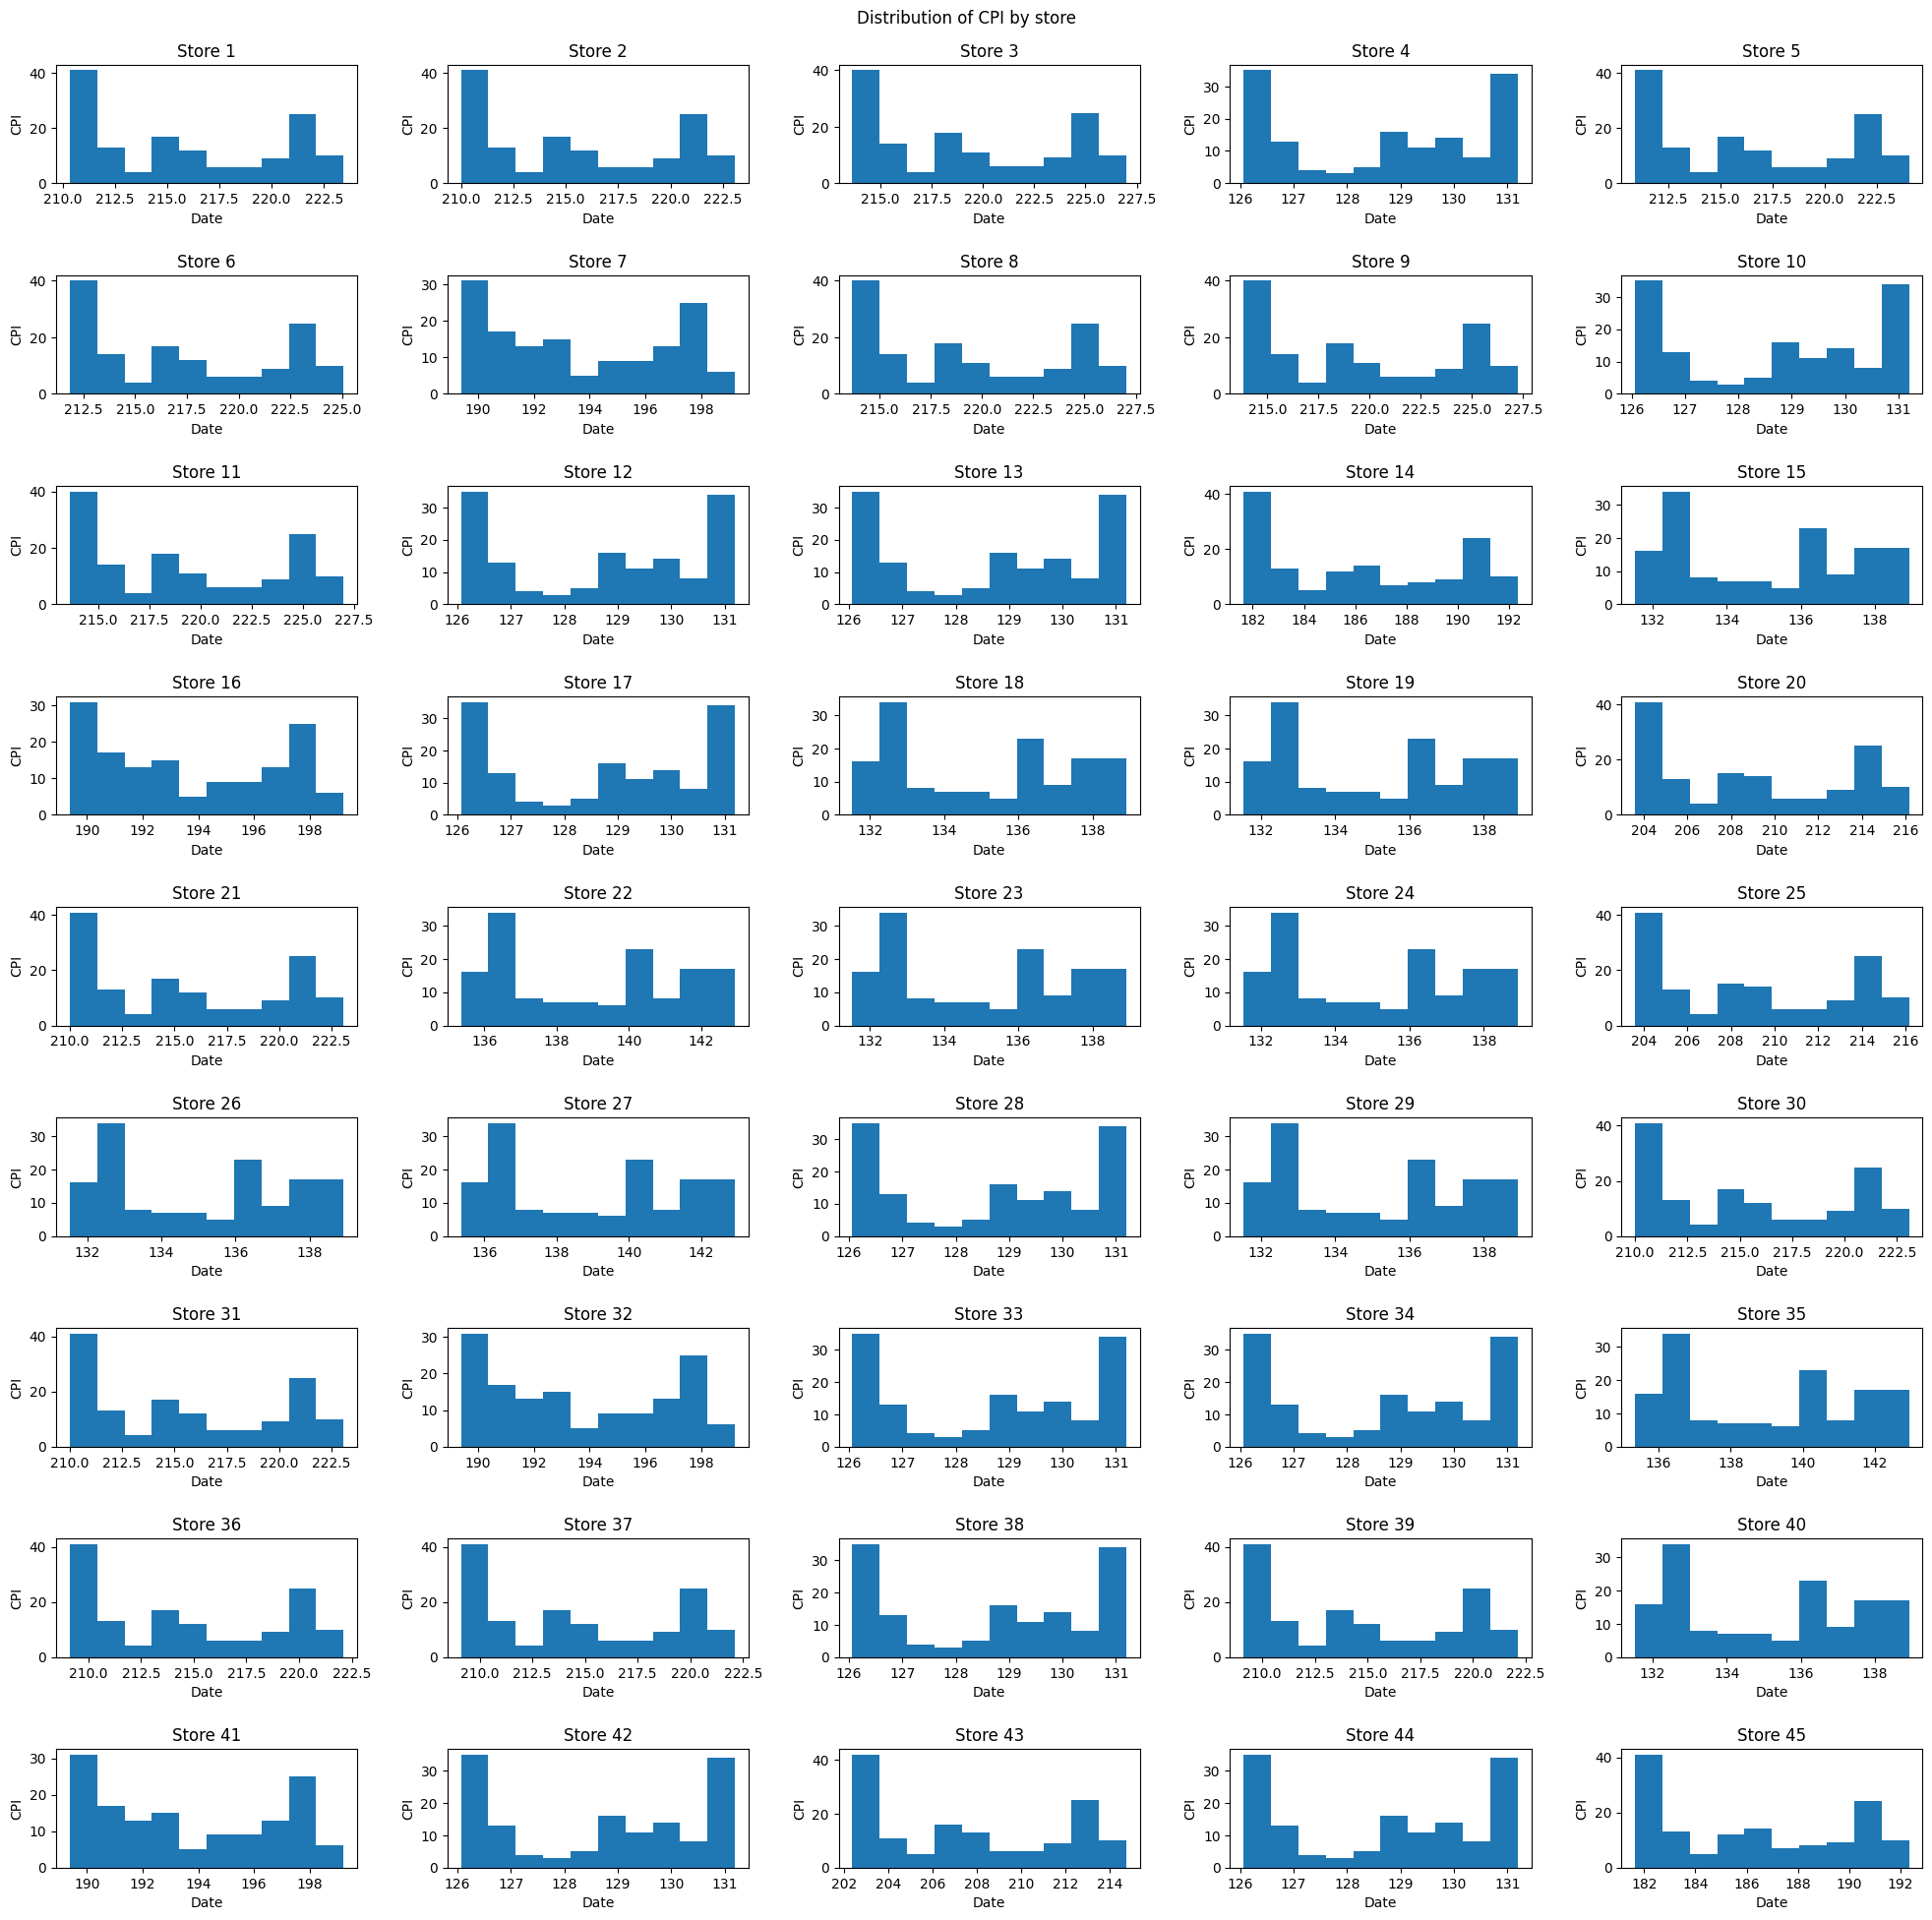

In [89]:
stores = sorted(walmart_ds["Store"].unique())
fig, axes = plt.subplots(9, 5, figsize=(20, 20))
axes = axes.flatten()
for index_store, store in enumerate(stores):
    df_store = walmart_ds[walmart_ds["Store"] == store]    
    axes[index_store].hist(df_store["CPI"])
    axes[index_store].set_title(f"Store {store}")
    axes[index_store].set_xlabel("Date")
    axes[index_store].set_ylabel("CPI")
plt.suptitle("Distribution of CPI by store")
plt.tight_layout(pad=2)
plt.show();

The gap in the CPI range between 150 and 180 can be explained by the fact that different stores operate within different CPI ranges. As result, combining the CPI distributions of multiple stores into a single histogram produces this gap.

### Missing Values

In [37]:
walmart_ds.isna().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Walmart dataset does not have missing values

### Holidays

In [36]:
walmart_ds[walmart_ds["Holiday_Flag"]== True]["Date"].unique()

<DatetimeArray>
['2010-02-12 00:00:00', '2010-09-10 00:00:00', '2010-11-26 00:00:00',
 '2010-12-31 00:00:00', '2011-02-11 00:00:00', '2011-09-09 00:00:00',
 '2011-11-25 00:00:00', '2011-12-30 00:00:00', '2012-02-10 00:00:00',
 '2012-09-07 00:00:00']
Length: 10, dtype: datetime64[ns]

The following holiday events are included in the dataset:
| Holiday | 2010 | 2011 | 2012 |
| --- | --- | --- | --- |
| Super Bowl | 12-Feb-2010 | 11-Feb-2011 | 10-Feb-2012 |
| Labour Day | 10-Sep-2010 | 9-Sep-2011 | 7-Sep-2012 |
| Thanksgiving | 26-Nov-2010 | 25-Nov-2011 |
| Christmas | 31-Dec-2010 | 30-Dec-2011 |

### Time Series Patterns

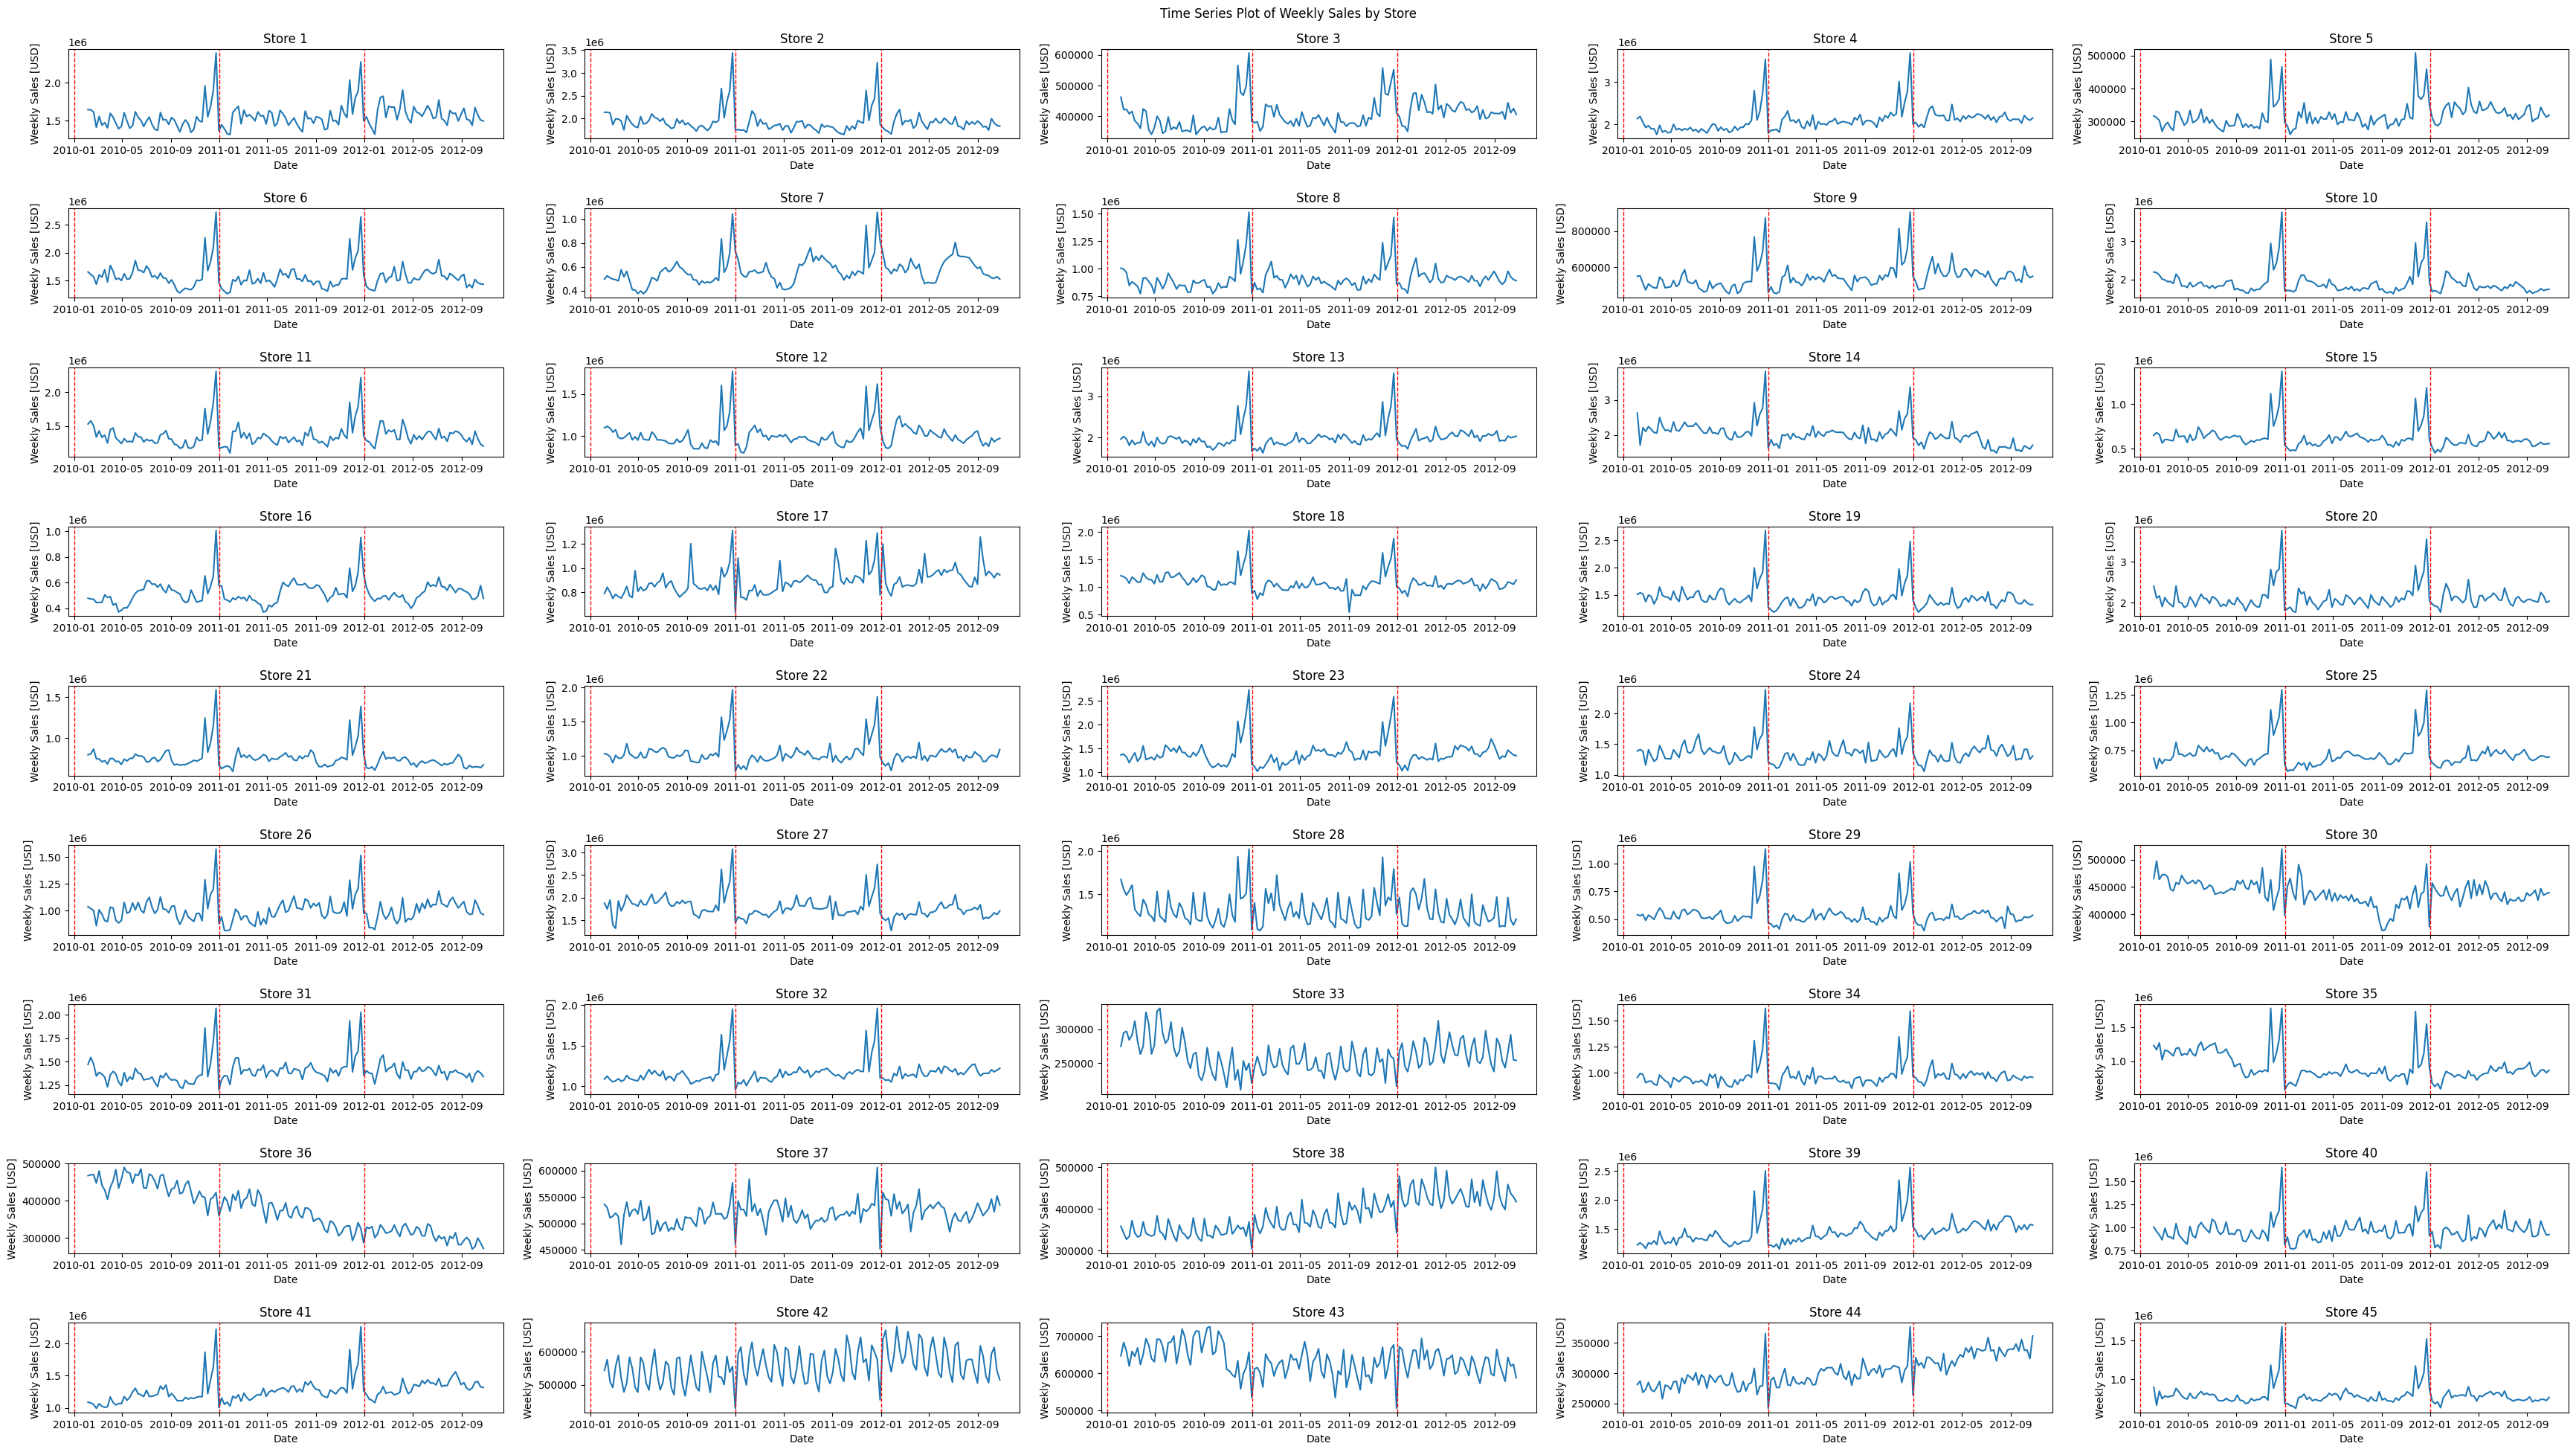

In [42]:
stores = sorted(walmart_ds["Store"].unique())
fig, axes = plt.subplots(9, 5, figsize=(35, 20))
axes = axes.flatten()
year_lines = [
    pd.to_datetime("2010-01-01"),
    pd.to_datetime("2011-01-01"),
    pd.to_datetime("2012-01-01")
]
for index_store, store in enumerate(stores):
    df_store = walmart_ds[walmart_ds["Store"] == store]    
    axes[index_store].plot(df_store["Date"], df_store["Weekly_Sales"])
    axes[index_store].set_title(f"Store {store}")
    axes[index_store].set_xlabel("Date")
    axes[index_store].set_ylabel("Weekly Sales [USD]")
    for line in year_lines:
            axes[index_store].axvline(line, color="red", linestyle="--", linewidth=1)
plt.suptitle("Time Series Plot of Weekly Sales by Store")
plt.tight_layout(pad=2)
plt.show()


| Patterns | Stores |
| --- | --- |
| Seasonality | All stores except 33, 36, 38, 42, and 43.|
| Trend behaviour | Store 36, 38, 42 and 44 do not show a well-defined seasonal pattern and instead exhibit local increasing or decreasing trends. |
| Anomalous values | Stores 18,  present anomalous weekly sales values around September 2011. |
| Structural change | Store 30, 33, 35, 43 shows a clear change in the sales level, indicanting a level shift.|



#### Anomalous values
For anomalous values, it would covenient to add a flag.
##### Store 18

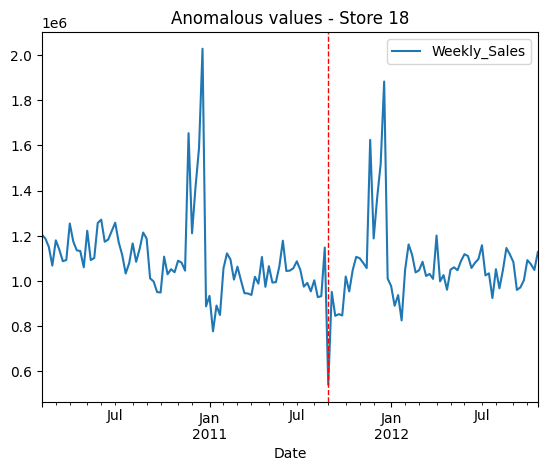

In [84]:
date = pd.to_datetime("2011-09-02")
walmart_ds[walmart_ds["Store"]==18].plot(x="Date", y="Weekly_Sales")
plt.axvline(x=date, linestyle="--", linewidth=1, color="red")
plt.title("Anomalous values - Store 18")
plt.show()

Record of date 2011-09-02 should have marked as a anomaly.

#### Structural Changes
For structural changes, it would covenient to add a flag.

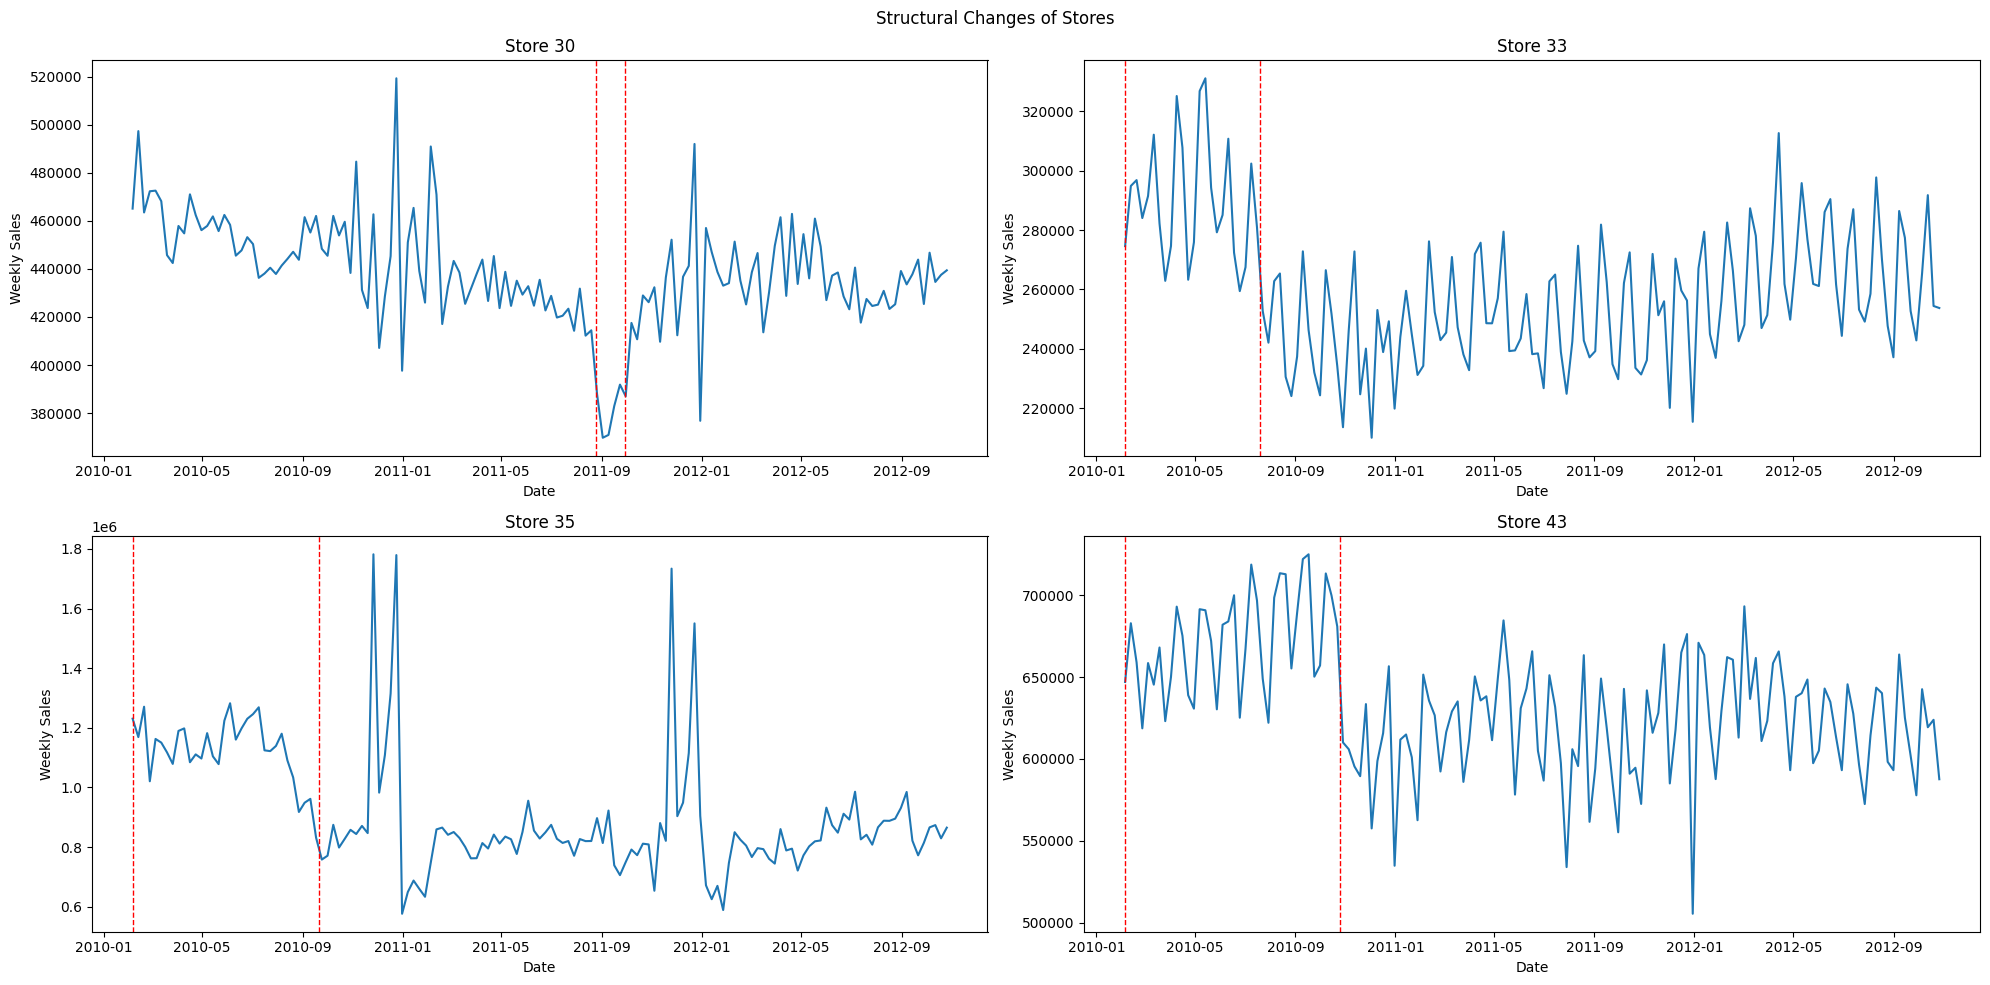

In [87]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20,10))
sc30_1 = pd.to_datetime("2011-08-25")
sc30_2 = pd.to_datetime("2011-09-29")
ax1.plot(walmart_ds[walmart_ds["Store"]==30]["Date"], walmart_ds[walmart_ds["Store"]==30]["Weekly_Sales"])
ax1.axvline(x=sc30_1, linestyle="--", linewidth=1, color="red")
ax1.axvline(x=sc30_2, linestyle="--", linewidth=1, color="red")
ax1.set_title("Store 30")
ax1.set_ylabel("Weekly Sales")
ax1.set_xlabel("Date")

sc33_1 = pd.to_datetime("2010-02-05")
sc33_2 = pd.to_datetime("2010-07-20")
ax2.plot(walmart_ds[walmart_ds["Store"]==33]["Date"], walmart_ds[walmart_ds["Store"]==33]["Weekly_Sales"])
ax2.axvline(x=sc33_1, linestyle="--", linewidth=1, color="red")
ax2.axvline(x=sc33_2, linestyle="--", linewidth=1, color="red")
ax2.set_title("Store 33")
ax2.set_ylabel("Weekly Sales")
ax2.set_xlabel("Date")

sc35_1 = pd.to_datetime("2010-02-05")
sc35_2 = pd.to_datetime("2010-09-20")
ax3.plot(walmart_ds[walmart_ds["Store"]==35]["Date"], walmart_ds[walmart_ds["Store"]==35]["Weekly_Sales"])
ax3.axvline(x=sc35_1, linestyle="--", linewidth=1, color="red")
ax3.axvline(x=sc35_2, linestyle="--", linewidth=1, color="red")
ax3.set_title("Store 35")
ax3.set_ylabel("Weekly Sales")
ax3.set_xlabel("Date")

sc43_1 = pd.to_datetime("2010-02-05")
sc43_2 = pd.to_datetime("2010-10-25")
ax4.plot(walmart_ds[walmart_ds["Store"]==43]["Date"], walmart_ds[walmart_ds["Store"]==43]["Weekly_Sales"])
ax4.axvline(x=sc43_1, linestyle="--", linewidth=1, color="red")
ax4.axvline(x=sc43_2, linestyle="--", linewidth=1, color="red")
ax4.set_title("Store 43")
ax4.set_ylabel("Weekly Sales")
ax4.set_xlabel("Date")
plt.suptitle("Structural Changes of Stores")
plt.tight_layout()
plt.show()

Stores should be marked as structural changes between ranges of time.
- Store 30: 2011-08-25 to 2011-09-29
- Store 33: 2010-02-05 to 2010-07-20
- Store 35: 2010-02-05 to 2010-09-20
- Store 43: 2010-02-05 to 2010-10-25

### Monthly Store Sales Distribution - Boxplots

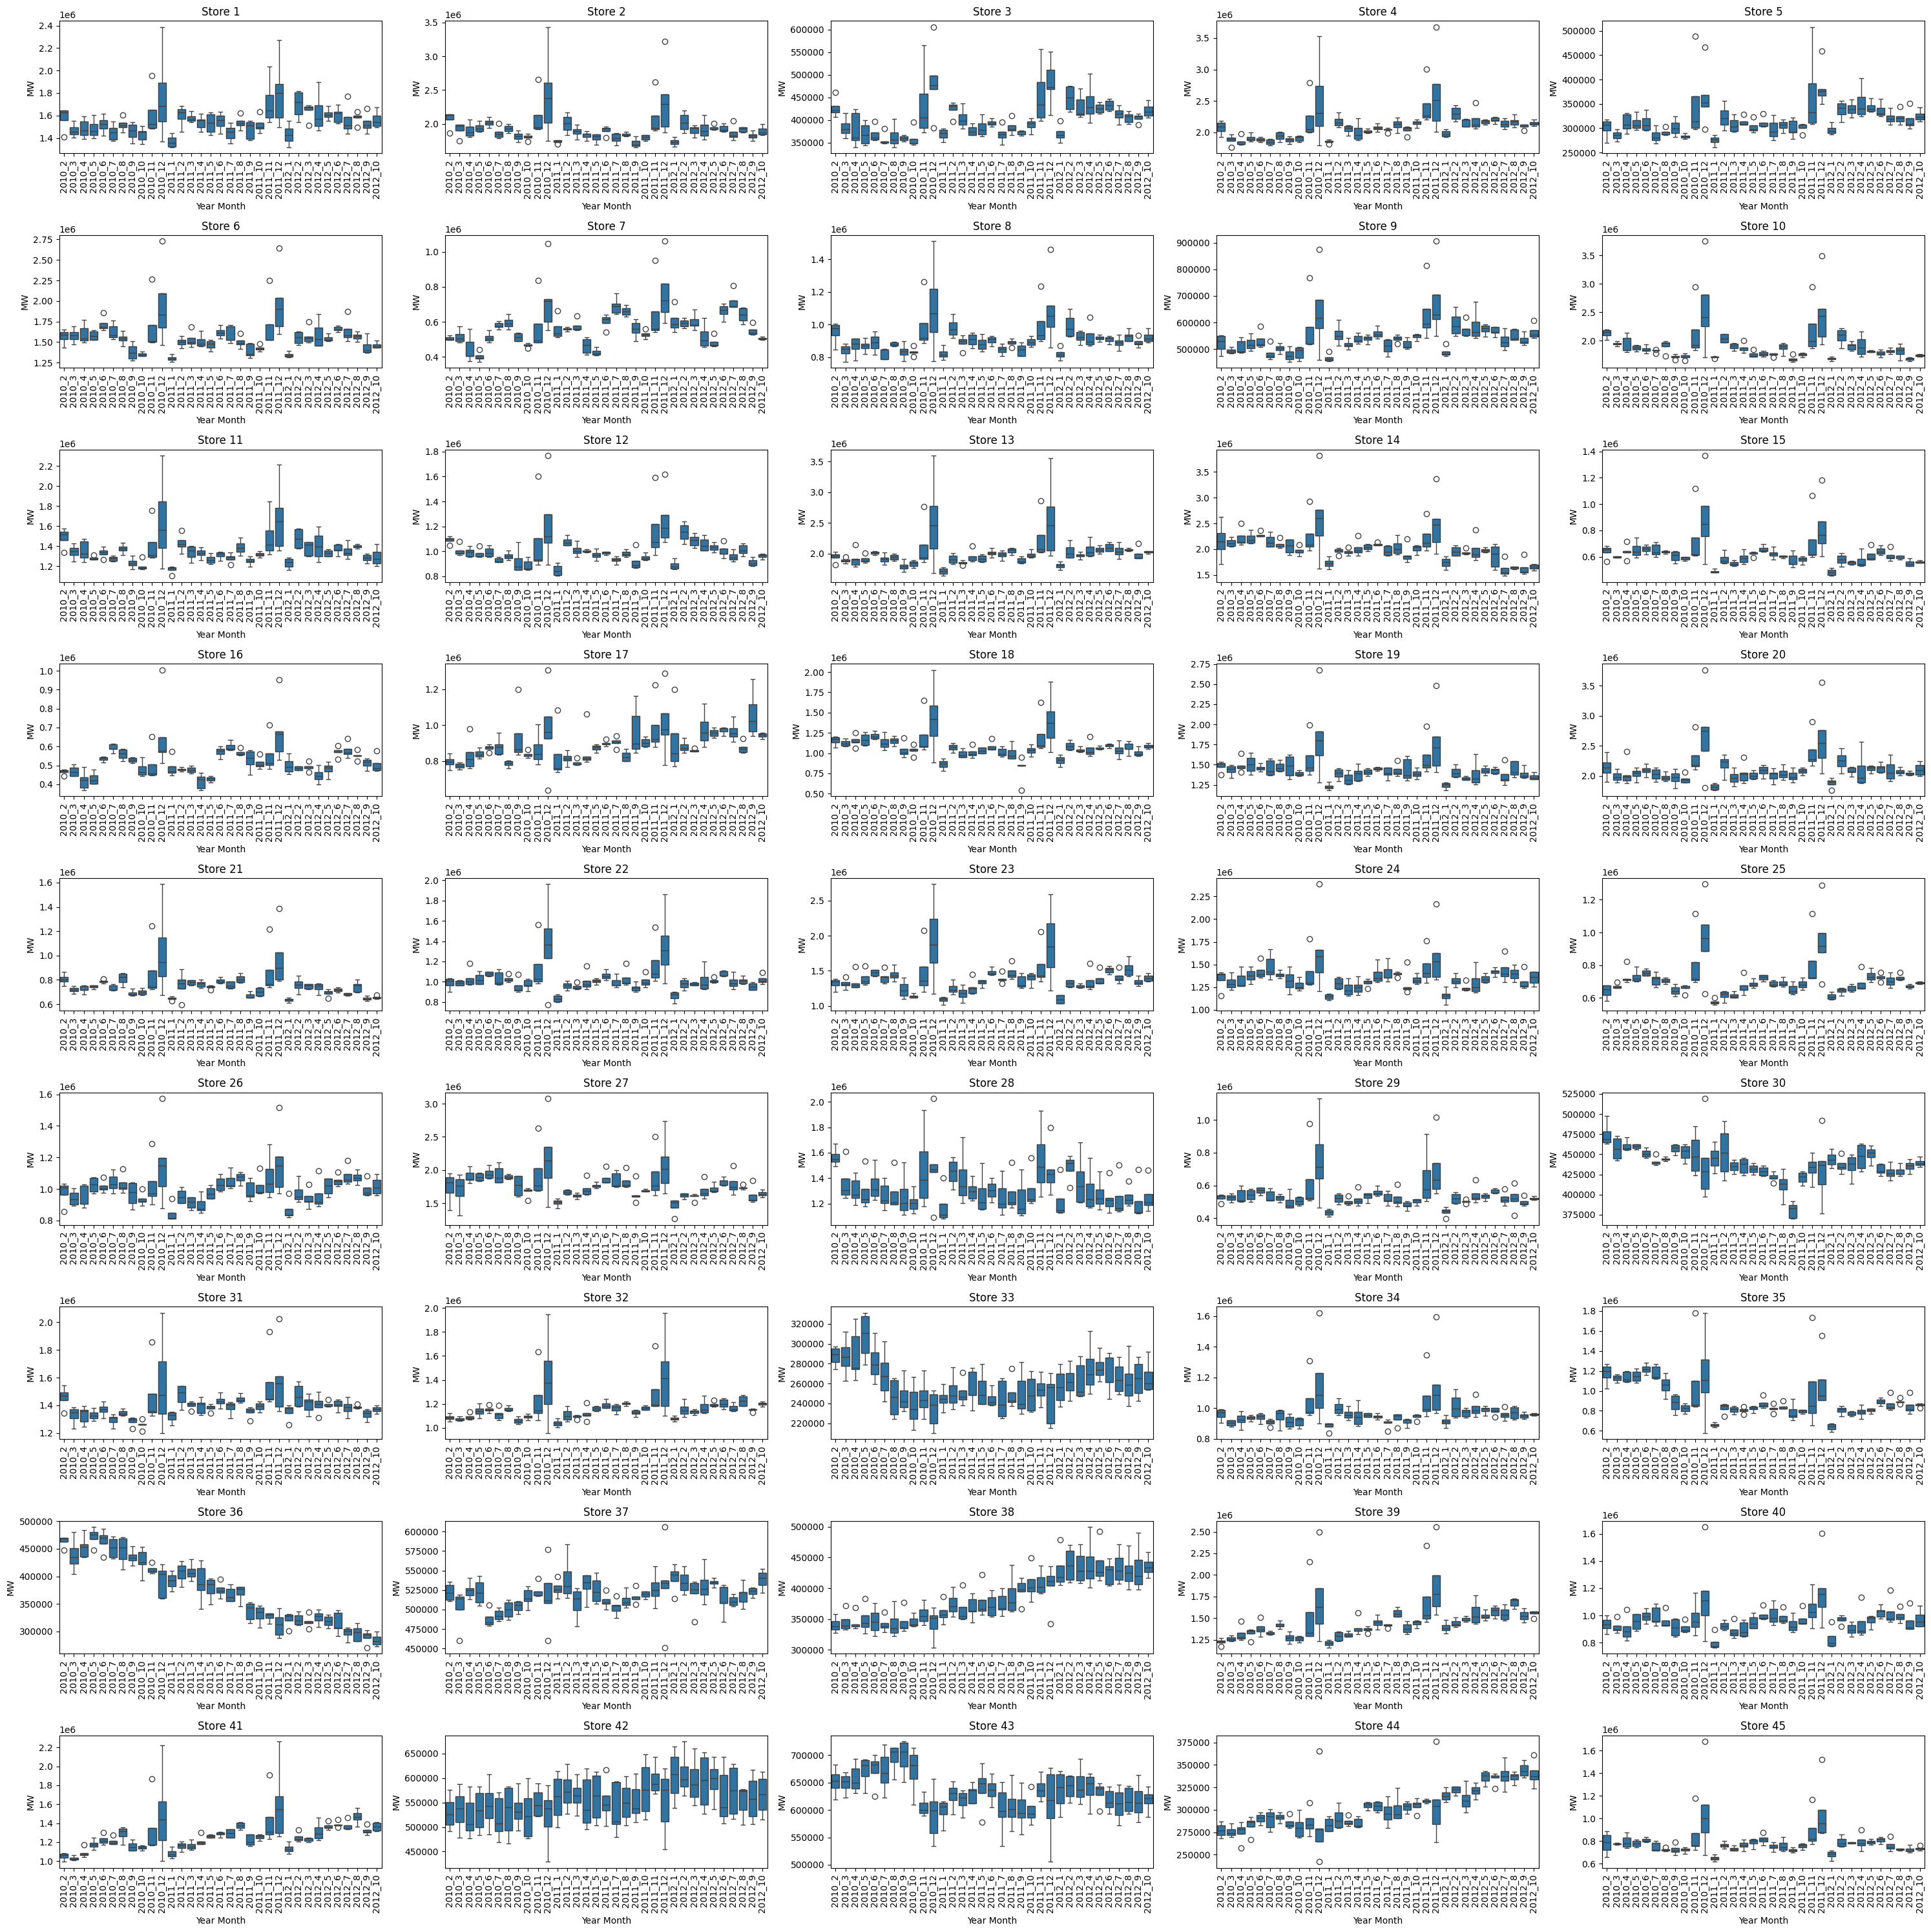

In [ ]:
walmart_ds["year"] = walmart_ds["Date"].dt.year
walmart_ds["month"] = walmart_ds["Date"].dt.month
walmart_ds["year_month"] = walmart_ds["Date"].apply(lambda x: str(x.year)+'_'+str(x.month))

stores = sorted(walmart_ds["Store"].unique())
fig, axes = plt.subplots(9, 5, figsize=(30, 30))
axes = axes.flatten()
for idx, store in enumerate(stores):
    df_store = walmart_ds[walmart_ds["Store"] == store]
    df_store = df_store.sort_values(by="Date").set_index('Date')
    axes[idx].set_title('Boxplot Year Month Distribution')
    axes[idx].tick_params(axis='x', rotation=90)
    axes[idx].set_xlabel('Year Month')
    axes[idx].set_ylabel('MW')
    sns.boxplot(
        x='year_month',
        y='Weekly_Sales',
        data=df_store,
        ax=axes[idx]
    )
    axes[idx].set_title(f"Store {store}")
plt.tight_layout()
plt.show()

Overall, sales exhibit lower variability from February to October, while dispersion increases in November and December. Specifically, stores 33, 38, 42, and 43 show particularly high monthly dispersion.

### Time Series Structure and Data Consistency

In [59]:
records_per_store = walmart_ds["Store"].value_counts()
print(f"Records per store (unique counts): {records_per_store.unique()}")
records_per_date = walmart_ds["Date"].value_counts()
print(f"Records per date (unique counts): {records_per_date.unique()}")
store_date_counts = walmart_ds.groupby(["Store", "Date"]).size()
print(f"Records per Store-Date pair: {store_date_counts.unique()}")
date_diffs = (
    walmart_ds["Date"]
    .drop_duplicates()
    .sort_values()
    .diff()
    .value_counts()
)
print("Time difference between consecutive dates:")
print(date_diffs)


Records per store (unique counts): [143]
Records per date (unique counts): [45]
Records per Store-Date pair: [1]
Time difference between consecutive dates:
Date
7 days    142
Name: count, dtype: int64


All stores are recorded regularly, with no gaps between dates. Therefore, there are no missing or duplicated dates that could introduce noise into the data.

Each store contains 143 observations, corresponding to 142 complete weekly intervals with a 7-day spacing.

## Data Feasibility

The data quality is generally good, except for 9 stores that present issues related to seasonality, trend behaviour, anomalous values, structural changes, and high dispersion.

Seasonality, trend behavior and variability are inherent to the way the data were collected and to store-specific circumstances that do not represent overall sales behavior. Modifying these components does not necessarily improve the model, since they affect the entire time series rather than isolated periods.

In contrast, anomalous values and structural changes can be addressed by introducing indicator or flag variables that signal when unusual events occur, allowing the model to capture their effects.

The data quantity is regular and consitent over time, with observations recorded at 7-day intervals from the first to the last date for each store. This corresponds to approximately two and a half seasonal cycles, which is sufficient for applying classical time series models.

Finally, a considerable part of the data preparation should focus on adding flags for anomalous values and structural changes, covering five cases in total.